In [21]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import pickle

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r'C:\Users\lenovo\Downloads\Amazon_Reviews.csv.zip',nrows=10000)

## Explore Data

In [3]:
df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [4]:
df .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Reviewer Name       10000 non-null  object
 1   Profile Link        10000 non-null  object
 2   Country             9999 non-null   object
 3   Review Count        10000 non-null  object
 4   Review Date         10000 non-null  object
 5   Rating              10000 non-null  object
 6   Review Title        10000 non-null  object
 7   Review Text         10000 non-null  object
 8   Date of Experience  10000 non-null  object
dtypes: object(9)
memory usage: 703.3+ KB


In [5]:
df.describe()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
count,10000,10000,9999,10000,10000,10000,10000,10000,10000
unique,8993,10000,127,154,9999,5,9558,9780,1078
top,customer,/users/66e8185ff1598352d6b3701a,GB,1 review,2022-10-05T12:13:39.000Z,Rated 1 out of 5 stars,Terrible customer service,Review text not found,"December 22, 2022"
freq,51,1,4190,2617,2,7846,19,218,27


In [6]:
df.isnull().sum()

Reviewer Name         0
Profile Link          0
Country               1
Review Count          0
Review Date           0
Rating                0
Review Title          0
Review Text           0
Date of Experience    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## Cleaning Data

In [8]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+','',text)
    text = re.sub(r'[^\w\s]','',text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##### 1.Apply Cleaning

In [9]:
print('Processing data,please wait ...')  
df['cleaned_review'] = df['Review Text'].apply(clean_text)
print('Data processing completed successfully !')

Processing data,please wait ...
Data processing completed successfully !


##### 2.Convert Rating column from 'object' to 'numeric'

In [10]:
# errors = 'coerce' will handle any strange characters by turning them into NaN 
df['Rating'] = df['Rating'].astype(str).str.extract('(\d+)').astype(float)

In [11]:
#Drop rows with NaN in Rating or Review Text to ensure clean data
df = df.dropna(subset=['Rating'])

##### 3.Prepare sentiment labels (skip neutral rating 3)

In [12]:
df = df[df['Rating'] != 3] #Drop neutral reviews
df['sentiment'] = df['Rating'].apply(lambda x: 1 if x > 3 else 0)
print('Pre-processing finished.')
print(f'Total processed reviews : {len(df)}')
print('\nSentiment counts :')
print(df['sentiment'].value_counts())

Pre-processing finished.
Total processed reviews : 9646

Sentiment counts :
sentiment
0    8419
1    1227
Name: count, dtype: int64


##### 4.Create the sentiment label (1 for positive , 0 for Negative)

In [13]:
df['sentiment'] = df['Rating'].apply(lambda x:1 if x > 3 else 0)
print('Pre-processing completed successfully !')
print(f'Total reviews after cleaning :{len(df)}')
print('\nSentiment Distribution :')
print(df['sentiment'].value_counts())

Pre-processing completed successfully !
Total reviews after cleaning :9646

Sentiment Distribution :
sentiment
0    8419
1    1227
Name: count, dtype: int64


In [14]:
df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience,cleaned_review,sentiment
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,1.0,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024",registered website tried order laptop entered ...,0
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,1.0,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024",multiple orders one turned driver phone door n...,0
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,1.0,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024",informed reprobates would going visit sick rel...,0
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,1.0,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024",bought amazon problems happy service price ama...,0
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,1.0,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024",could give lower rate would cancelled amazon p...,0


## Create Model

In [15]:
x = df['Review Text']
y = df['sentiment']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
print('Data splitting completed')
print(f"Total training samples :{x_train.shape[0]}")
print(f'Total testing samples :{x_test.shape[0]}')

Data splitting completed
Total training samples :7716
Total testing samples :1930


In [17]:
#Initialize the vectorizer
vectorizer = TfidfVectorizer(max_features=5000)
#Learn the vocabulary and transform training data
x_train_tfidf = vectorizer.fit_transform(x_train)
#Transform testing data(using the same vocabulary)
x_test_tfidf = vectorizer.transform(x_test)
print('Text to numbers conversion (vectorization) id done.')

Text to numbers conversion (vectorization) id done.


##### Model Training

In [18]:
model = LogisticRegression()
model.fit(x_train_tfidf,y_train)
y_pred = model.predict(x_test_tfidf)
accuracy = accuracy_score(y_test,y_pred)
print(f'Training completed . Model Accuracy :{accuracy*100:.2f}%')

Training completed . Model Accuracy :93.99%


In [22]:
with open('Sentiment_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open ('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer,f)

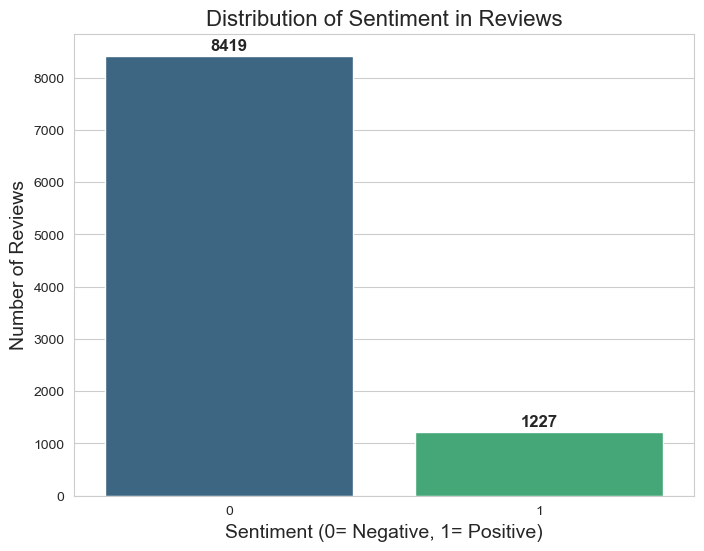

In [19]:
sns.set_style('whitegrid')
plt.figure(figsize = (8,6))
ax = sns.countplot(x='sentiment',data=df ,palette = 'viridis')

plt.title('Distribution of Sentiment in Reviews', fontsize=16)
plt.xlabel('Sentiment (0= Negative, 1= Positive)', fontsize=14)
plt.ylabel('Number of Reviews', fontsize=14)

for p in ax.patches :
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2. , height+100, f'{int(height)}',ha='center' ,fontsize=12, fontweight='bold' )
plt.show()

## Manual Testing

In [20]:
def predict_my_review(text):
    try :
        if text is None :
            return "Please enter some value"
        cleaned = clean_text(text)
        if cleaned is None :
            return 'Review is empty after cleaning'
        text_vector = vectorizer.transform([str(cleaned)])    
        prediction = model.predict(text_vector)
        if prediction[0] == 1:
            return 'Positive'
        else :
            return 'Negative'
    except Exception as e:
        return f'Error :{str(e)}'
user_input = input('Enter a review to test : ')
result = predict_my_review(user_input)
print(f'Tha model says :{result}')

Enter a review to test :  not bad


Tha model says :Negative


## 